In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.andrews import encode

In [2]:
df = pd.read_csv("../data/winequality-red.csv", sep=";")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
X = df.drop(columns=["quality"])
y = df["quality"]

print("Forma del dataset:", df.shape)
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("Variables usadas:", list(X.columns))
print("Calidades disponibles:", sorted(y.unique()))

Forma del dataset: (1599, 12)
Forma de X: (1599, 11)
Forma de y: (1599,)
Variables usadas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Calidades disponibles: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


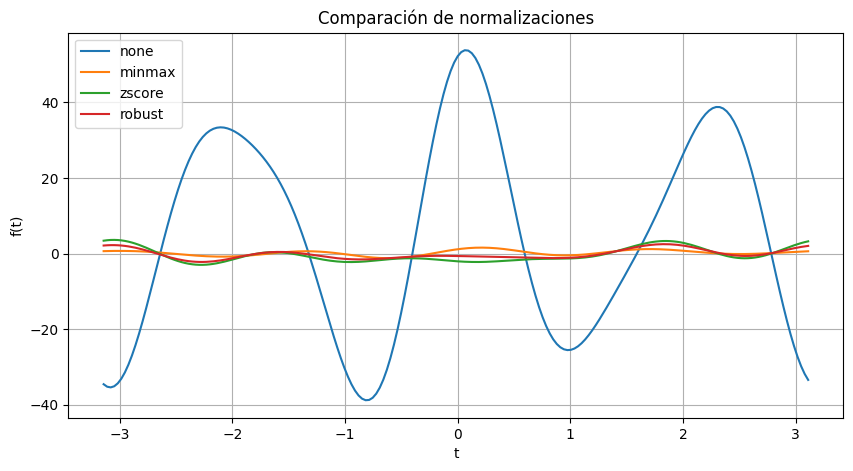

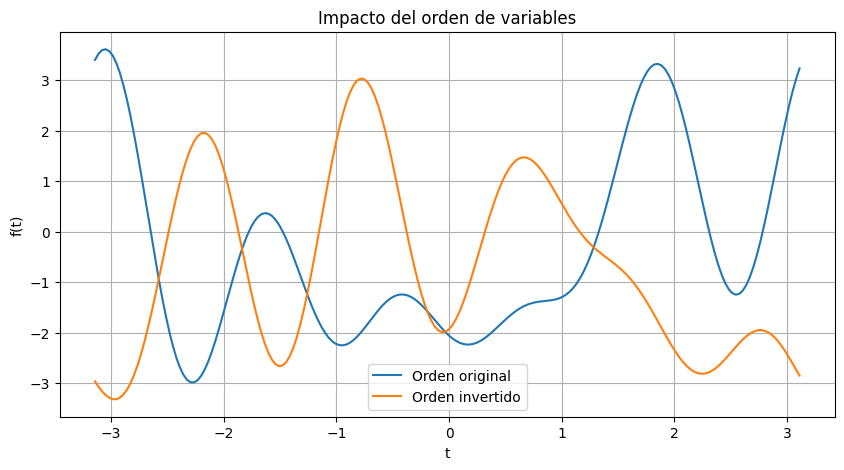

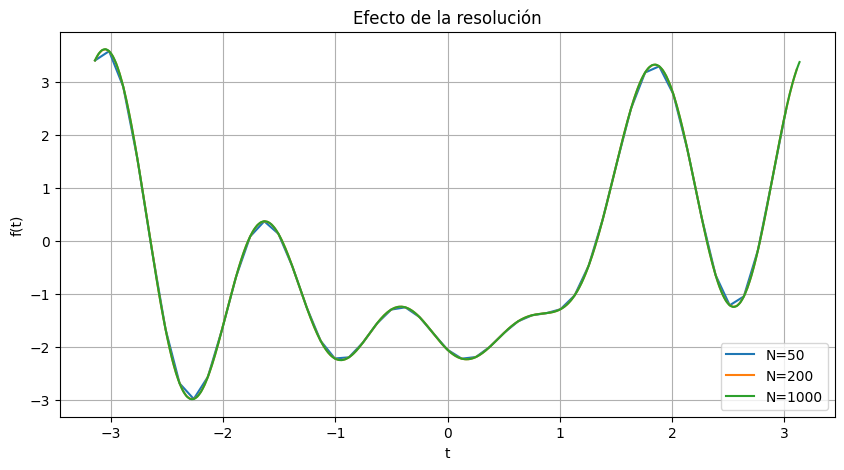

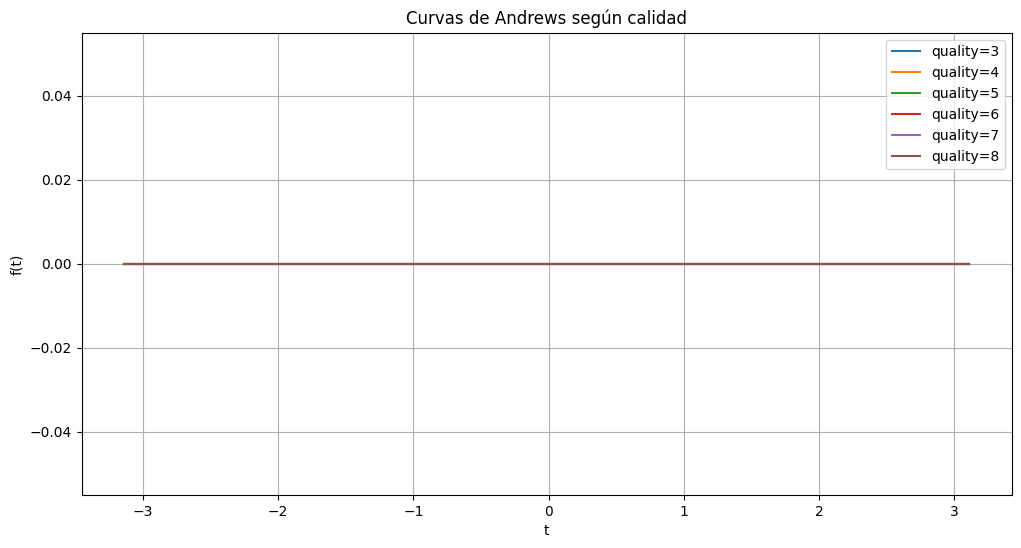

In [8]:

# ========================= 
# 1. Comparar normalizaciones 
# =========================

sample = X

curves_none, t = encode(sample, normalize="none", return_t=True)
curves_minmax = encode(sample, normalize="minmax")
curves_zscore = encode(sample, normalize="zscore")
curves_robust = encode(sample, normalize="robust")

plt.figure(figsize=(10, 5))

plt.plot(t, curves_none[0], label="none")
plt.plot(t, curves_minmax[0], label="minmax")
plt.plot(t, curves_zscore[0], label="zscore")
plt.plot(t, curves_robust[0], label="robust")

plt.title("Comparación de normalizaciones")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 2. Comparar orden de variables
# =========================

original_order = list(range(X.shape[1]))
reverse_order = original_order[::-1]

curves_original, t = encode(
    sample,
    normalize="zscore",
    order=original_order,
    return_t=True
)

curves_reverse = encode(
    sample,
    normalize="zscore",
    order=reverse_order
)

plt.figure(figsize=(10, 5))

plt.plot(t, curves_original[0], label="Orden original")
plt.plot(t, curves_reverse[0], label="Orden invertido")

plt.title("Impacto del orden de variables")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 3. Comparar resolución N
# =========================

curve_50, t50 = encode(sample, N=50, return_t=True)
curve_200, t200 = encode(sample, N=200, return_t=True)
curve_1000, t1000 = encode(sample, N=1000, return_t=True)

plt.figure(figsize=(10, 5))

plt.plot(t50, curve_50[0], label="N=50")
plt.plot(t200, curve_200[0], label="N=200")
plt.plot(t1000, curve_1000[0], label="N=1000")

plt.title("Efecto de la resolución")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 4. Curvas según calidad
# =========================

qualities = [3,4,5,6,7,8]

plt.figure(figsize=(12, 6))

for q in qualities:
    idx = y[y == q].index[0]

    sample_q = X.loc[[idx]]

    curve_q, t = encode(
        sample_q,
        normalize="zscore",
        return_t=True
    )

    plt.plot(t, curve_q[0], label=f"quality={q}")

plt.title("Curvas de Andrews según calidad")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.legend()
plt.grid(True)
plt.show()
